In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("obulisainaren/forest-fire-c4")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'forest-fire-c4' dataset.
Path to dataset files: /kaggle/input/forest-fire-c4
Contents of base_path (/kaggle/input):
['forest-fire-c4']
Contents of path (/kaggle/input/forest-fire-c4):
['Forect Fire', 'README.md']


In [ ]:
import os

# Point to the 'Forect Fire' directory inside the dataset
data_path = os.path.join(path, 'Forect Fire')

# List forest fire class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Forest fire classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Forest fire classes found: ['Forest Fire_Tester', 'Forest Fire_Dataset']



--- Displaying Sample Images from Dataset (/kaggle/input/forest-fire-c4/Forect Fire) ---
Found 4823 images. Displaying 6 sample images:


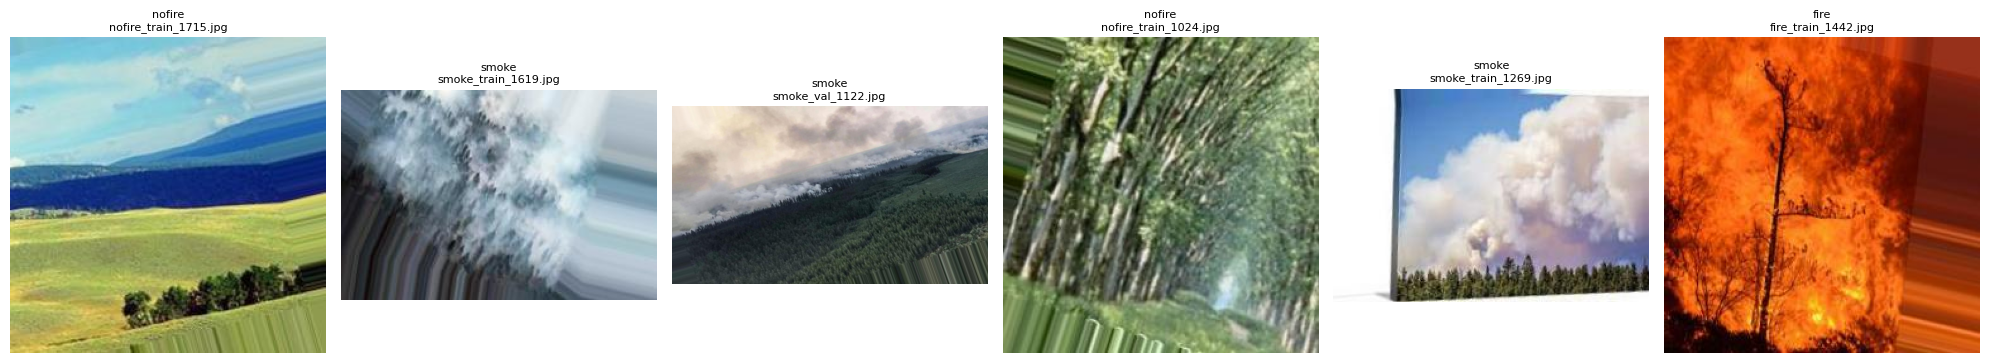

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the updated path pointing to the images folder
data_path = os.path.join(path, 'Forect Fire')
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Define data transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(data_path, transform=data_transforms)

# Split into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Handle Class Imbalance using WeightedRandomSampler
targets = [dataset.targets[i] for i in train_dataset.indices]
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in targets])
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize ResNet model with correct weight parameter
model = models.resnet18(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(f'Classes: {dataset.classes}')
print('Using WeightedRandomSampler to address imbalance.')

Classes: ['Forest Fire_Dataset', 'Forest Fire_Tester']
Using WeightedRandomSampler to address imbalance.


In [ ]:
import collections

# Check the distribution of classes in the dataset
class_counts = collections.Counter(dataset.targets)
for idx, count in class_counts.items():
    print(f"Class '{dataset.classes[idx]}': {count} images")

# Re-create loaders with a shuffle for validation to see if the metric changes
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

Class 'Forest Fire_Dataset': 4800 images
Class 'Forest Fire_Tester': 23 images


Detailed Validation Report:
Classification Report:
                     precision    recall  f1-score   support

Forest Fire_Dataset       1.00      0.97      0.98       961
 Forest Fire_Tester       0.03      0.25      0.06         4

           accuracy                           0.97       965
          macro avg       0.52      0.61      0.52       965
       weighted avg       0.99      0.97      0.98       965



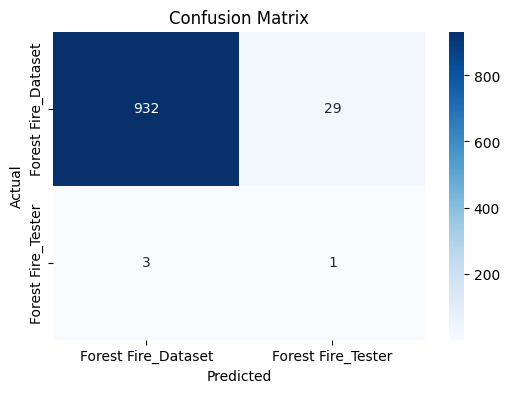

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n--- Final Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=dataset.classes, yticklabels=dataset.classes, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Verification of Minority Class Learning)')
    plt.show()

evaluate_model(model, val_loader)

In [ ]:
num_epochs = 10
history = {'train_loss': [], 'val_acc': []}

print("Starting training with WeightedRandomSampler to address class imbalance...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(epoch_loss)

    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)

    val_acc = correct.double() / len(val_loader.dataset)
    history['val_acc'].append(val_acc.item())
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.4f}')

Starting training with WeightedRandomSampler to address class imbalance...
Epoch 1/10 - Loss: 0.0149, Val Acc: 0.9969
Epoch 2/10 - Loss: 0.0068, Val Acc: 0.9959
Epoch 3/10 - Loss: 0.0024, Val Acc: 0.9969
Epoch 4/10 - Loss: 0.0022, Val Acc: 0.9969
Epoch 5/10 - Loss: 0.0013, Val Acc: 0.9969
Epoch 6/10 - Loss: 0.0012, Val Acc: 0.9959
Epoch 7/10 - Loss: 0.0007, Val Acc: 0.9959
Epoch 8/10 - Loss: 0.0007, Val Acc: 0.9959
Epoch 9/10 - Loss: 0.0006, Val Acc: 0.9959
Epoch 10/10 - Loss: 0.0006, Val Acc: 0.9969


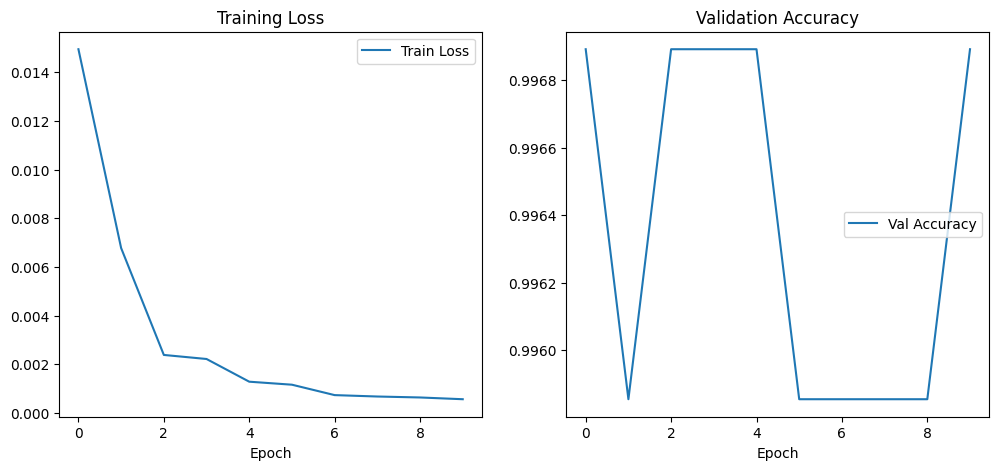

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()